<a href="https://colab.research.google.com/github/Asfahany/PPE-Detection-OilGas-Safety/blob/main/PPE_Detection_OilGas_CaseStudy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI/ML PPE Compliance Detection for Oil & Gas Rig Safety (i-CCTV)

**Studi Kasus:** Penerapan *Computer Vision* (YOLOv8 Object Detection) untuk deteksi kepatuhan Alat Pelindung Diri (APD/PPE) secara otomatis, terinspirasi dari studi kasus **"i-CCTV Object Detection"** pada operasi Rig Drilling & Completion (PHR WK Rokan) yang dibahas dalam workshop *AI and Machine Learning in Oil & Gas Industry* (Dr. Joko Nugroho, 2026).

**Penulis:** *(Muh. Asfahany Al Ghifari)*
**Tanggal:** 16 Agustus 2026

---

##Latar Belakang & Konteks Bisnis

Operasi pengeboran minyak dan gas bumi (*migas*) merupakan kegiatan berisiko tinggi (*high-risk operation*) yang melibatkan ribuan personel dan puluhan ribu jam kerja setiap tahunnya. Tingginya intensitas kerja di area kritis, seperti aktivitas lifting, rigging, dan drilling. Yang mana menuntut penerapan standar Kesehatan, Keselamatan, Keamanan, dan Lingkungan (*HSSE*) yang sangat ketat. Berdasarkan referensi industri (SPE-214018-MS: "AI-Based Under Suspended Load Detection — Case Study in Rokan Drilling & Completion Operation"), aktivitas *lifting & rigging* menyumbang sekitar **30% dari total temuan keselamatan di lapangan.**

Sebelum adanya pengawasan berbasis teknologi, pemantauan CCTV di area rig dilakukan secara manual oleh **2 personel HSSE Observer untuk 2 rig sekaligus.** Metode konvensional ini terbukti tidak efektif dan sulit mengimbangi pesatnya ekspansi operasional, di mana jumlah rig aktif melonjak signifikan dari 34 menjadi 78 rig dalam kurun waktu dua tahun terakhir.

**Pain point:**
- Pengawasan manual CCTV tidak *scalable* seiring pertumbuhan jumlah rig.
- Keterlambatan deteksi pelanggaran APD (helm, vest, masker) meningkatkan risiko kecelakaan kerja.
- HSSE Specialist rentan *fatigue* karena harus memantau banyak layar sekaligus.

**Solusi yang didemonstrasikan pada notebook ini:**

Sebuah *pipeline* AI berbasis **YOLOv8 object detection** yang  mendeteksi pekerja & status kelengkapan APD dari citra CCTV rig, dan menerapkan *business rule layer* untuk mengklasifikasikan setiap pekerja sebagai **COMPLIANT** atau **VIOLATION**, meniru alur notifikasi HSSE (*"Any findings will be notified on MS Teams"*) yang dijelaskan pada Case Study 2 di materi workshop.

> Catatan transparansi: Karena dataset CCTV rig migas yang sesungguhnya bersifat internal/rahasia perusahaan, sehingga data ini menggunakan **dataset publik "Construction Site Safety" (Roboflow, 2.801 citra, lisensi terbuka)** sebagai *proxy* domain yang sangat mirip (pekerja + APD di lingkungan konstruksi/industrial outdoor) untuk mendemonstrasikan keseluruhan *pipeline*, mulai dari EDA, *transfer learning* YOLOv8, evaluasi, hingga *business logic* kepatuhan APD. Model *fine-tuned* (YOLOv8s, 200 epoch) diambil dari proyek open-source [VoxDroid/Construction-Site-Safety-PPE-Detection](https://github.com/VoxDroid/Construction-Site-Safety-PPE-Detection) (MIT License) dan **dievaluasi ulang secara independen**. Pada implementasi produksi di lingkungan migas nyata, langkah selanjutnya adalah *fine-tuning* lanjutan menggunakan citra CCTV rig aktual (lihat bagian *Limitations & Future Work*).

##Framework Kerja

| Fase | Aktivitas |
|---|---|
| Business Understanding | Bagian 1 (di atas) |
| Data Understanding | Bagian 3 — EDA dataset |
| Data Preparation | Bagian 3 — parsing label YOLO |
| Modeling | Bagian 4 — YOLOv8s transfer learning |
| Evaluation | Bagian 5 — mAP, precision, recall, confusion matrix |
| Deployment (simulasi) | Bagian 6–7 — inference + compliance business logic + dashboard ringkas |


## Setup & Import Library



In [ ]:
import os, glob, random
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2

!pip install ultralytics
from ultralytics import YOLO

random.seed(42)
np.random.seed(42)

# Unzip the project data if not already unzipped
if not Path("data").exists() or not Path("model").exists():
    print("Mengextract ppe_project_local.zip...")
    !unzip -q ppe_project_local.zip -d .
    print("Extract selesai.")

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data" / "test"
IMG_DIR = DATA_DIR / "images"
LBL_DIR = DATA_DIR / "labels"
MODEL_PATH = str(PROJECT_ROOT / "model" / "ppe_yolov8s_best.pt")
FIG_DIR = PROJECT_ROOT / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = ['Hardhat', 'Mask', 'NO-Hardhat', 'NO-Mask', 'NO-Safety Vest',
               'Person', 'Safety Cone', 'Safety Vest', 'machinery', 'vehicle']

n_img = len(list(IMG_DIR.glob('*.jpg')))
n_lbl = len(list(LBL_DIR.glob('*.txt')))
assert n_img > 0 and n_lbl > 0, (
    f"Data tidak ditemukan di {DATA_DIR}. Pastikan notebook ini dibuka dari DALAM folder project "
    f"(folder yang berisi subfolder 'data' dan 'model' hasil extract ppe_project_local.zip)."
)
print(f"Jumlah gambar test-set : {n_img}")
print(f"Jumlah label test-set  : {n_lbl}")
print(f"Kelas yang dideteksi   : {CLASS_NAMES}")

Jumlah gambar test-set : 82
Jumlah label test-set  : 82
Kelas yang dideteksi   : ['Hardhat', 'Mask', 'NO-Hardhat', 'NO-Mask', 'NO-Safety Vest', 'Person', 'Safety Cone', 'Safety Vest', 'machinery', 'vehicle']


## Exploratory Data Analysis (EDA)


In [ ]:
class_counter = Counter()
boxes_per_image = []

for lbl_file in LBL_DIR.glob("*.txt"):
    with open(lbl_file) as f:
        lines = [l.strip() for l in f if l.strip()]
    boxes_per_image.append(len(lines))
    for line in lines:
        cls_id = int(line.split()[0])
        class_counter[CLASS_NAMES[cls_id]] += 1

eda_df = pd.DataFrame(sorted(class_counter.items(), key=lambda x: -x[1]),
                       columns=["class", "instance_count"])
eda_df


,class,instance_count
0,Person,174
1,Hardhat,110
2,Safety Cone,92
3,NO-Safety Vest,90
4,NO-Mask,79
5,Safety Vest,61
6,machinery,44
7,NO-Hardhat,41
8,vehicle,41
9,Mask,28


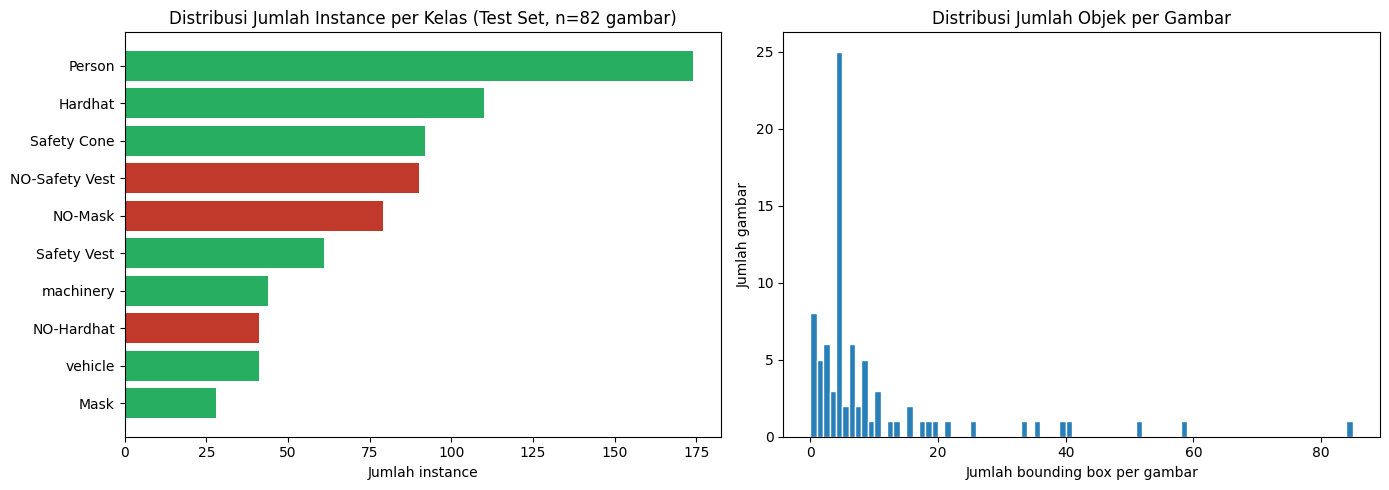

Rata-rata objek per gambar: 9.3
Total instance ter-anotasi: 760


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#c0392b' if c.startswith('NO-') else '#27ae60' for c in eda_df['class']]
axes[0].barh(eda_df['class'], eda_df['instance_count'], color=colors)
axes[0].invert_yaxis()
axes[0].set_title("Distribusi Jumlah Instance per Kelas (Test Set, n=82 gambar)")
axes[0].set_xlabel("Jumlah instance")

axes[1].hist(boxes_per_image, bins=range(0, max(boxes_per_image)+2), color='#2980b9', edgecolor='white')
axes[1].set_title("Distribusi Jumlah Objek per Gambar")
axes[1].set_xlabel("Jumlah bounding box per gambar")
axes[1].set_ylabel("Jumlah gambar")

plt.tight_layout()
plt.savefig(str(FIG_DIR / "eda_class_distribution.png"), dpi=130)
plt.show()
plt.close('all')
import gc; gc.collect()

print(f"Rata-rata objek per gambar: {np.mean(boxes_per_image):.1f}")
print(f"Total instance ter-anotasi: {sum(class_counter.values())}")


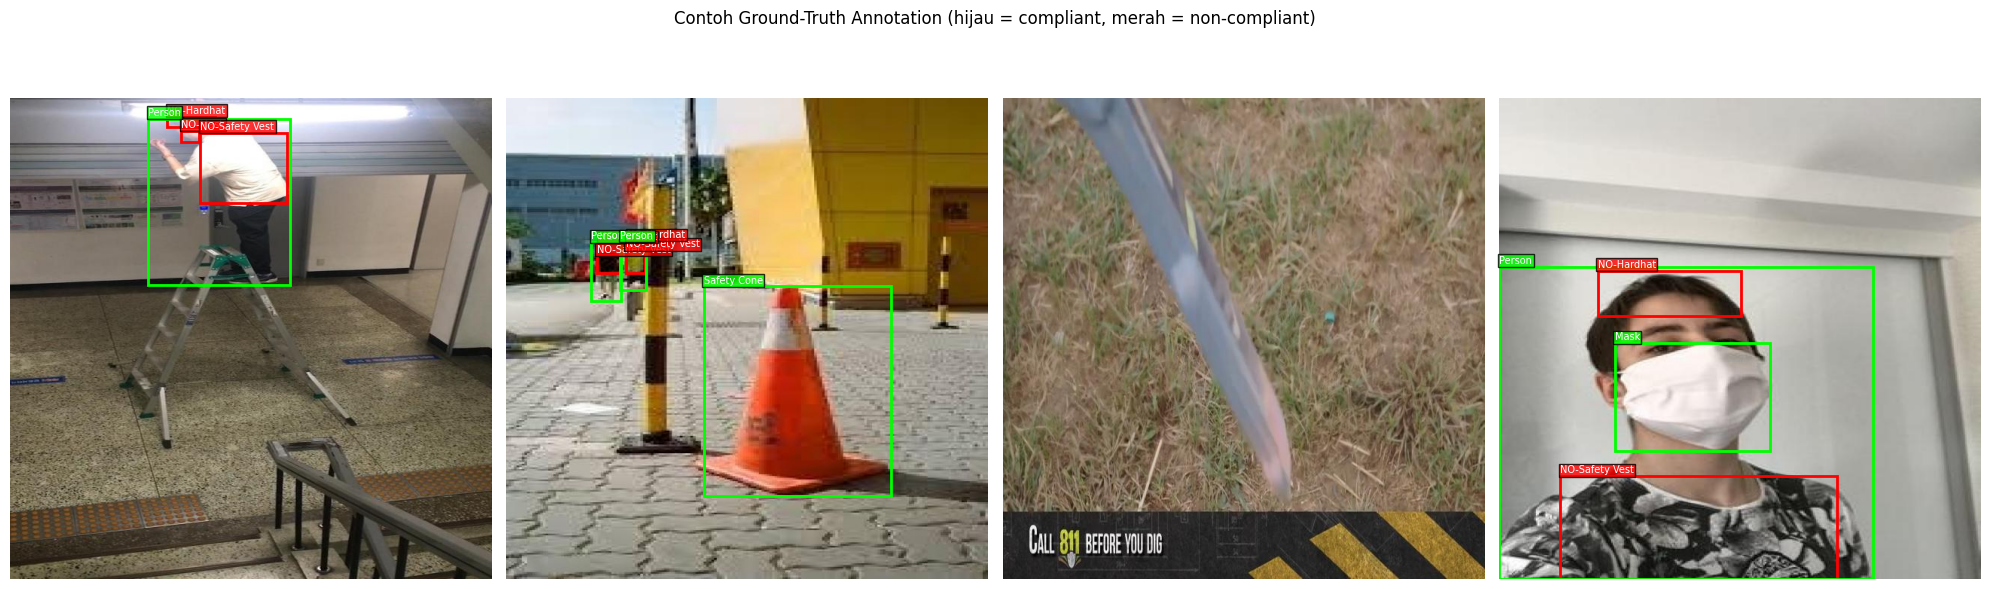

10868

In [ ]:
# Visualisasi sampel ground-truth bounding box pada citra asli
def draw_boxes(ax, img_path, lbl_path, class_names):
    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    ax.imshow(img)
    if lbl_path.exists():
        with open(lbl_path) as f:
            for line in f:
                parts = line.split()
                cls_id = int(parts[0])
                xc, yc, bw, bh = [float(v) for v in parts[1:5]]
                x1, y1 = (xc - bw/2) * w, (yc - bh/2) * h
                box_w, box_h = bw * w, bh * h
                color = 'red' if class_names[cls_id].startswith('NO-') else 'lime'
                rect = patches.Rectangle((x1, y1), box_w, box_h, linewidth=2,
                                          edgecolor=color, facecolor='none')
                ax.add_patch(rect)
                ax.text(x1, max(y1-4, 0), class_names[cls_id], color='white', fontsize=7,
                        bbox=dict(facecolor=color, alpha=0.8, pad=1))
    ax.axis('off')

sample_images = random.sample(list(IMG_DIR.glob("*.jpg")), 4)
fig, axes = plt.subplots(1, 4, figsize=(20, 6))
for ax, img_path in zip(axes, sample_images):
    lbl_path = LBL_DIR / (img_path.stem + ".txt")
    draw_boxes(ax, img_path, lbl_path, CLASS_NAMES)
fig.suptitle("Contoh Ground-Truth Annotation (hijau = compliant, merah = non-compliant)", y=1.02)
plt.tight_layout()
plt.savefig(str(FIG_DIR / "eda_sample_ground_truth.png"), dpi=130, bbox_inches='tight')
plt.show()
plt.close('all')
import gc; gc.collect()


##Model — YOLOv8s Transfer Learning

Model menggunakan arsitektur **YOLOv8s** (Ultralytics) yang di-*fine-tune* dari bobot pre-trained COCO menuju 10 kelas domain APD. Ringkasan konfigurasi training (dijalankan oleh sumber referensi pada GPU NVIDIA RTX 5060 Ti, 200 epoch, ± 1.9 jam):

| Parameter | Nilai |
|---|---|
| Arsitektur | YOLOv8s |
| Epoch | 200 |
| Batch size | 16 |
| Image size | 640×640 |
| Optimizer | Auto (adaptive) |
| Data split | Train 2605 / Valid 114 / Test 82 |

Pada kali ini kita **memuat bobot hasil training tersebut** dan melakukan **evaluasi independen** pada 82 citra *test set* yang tidak dilihat sama sekali selama training/validasi serta, merepresentasikan estimasi performa model saat *deployment* di lapangan.

In [ ]:

model = YOLO(MODEL_PATH)
print(model.info())
print("\nKelas model:", model.names)


Model summary: 129 layers, 11,139,470 parameters, 0 gradients, 28.7 GFLOPs
(129, 11139470, 0, 28.6614016)

Kelas model: {0: 'Hardhat', 1: 'Mask', 2: 'NO-Hardhat', 3: 'NO-Mask', 4: 'NO-Safety Vest', 5: 'Person', 6: 'Safety Cone', 7: 'Safety Vest', 8: 'machinery', 9: 'vehicle'}


##Evaluasi Model pada Test Set

In [ ]:
import yaml

# Create a dictionary for class names from the CLASS_NAMES list
class_names_dict = {i: name for i, name in enumerate(CLASS_NAMES)}

# Define the data for the data.yaml file with correct paths for Colab
data_yaml_content = {
    'path': str(PROJECT_ROOT / "data"), # Base path for the dataset
    'train': 'train/images', # Placeholder for train images, if applicable
    'val': 'test/images',    # Validation images are in the test set's image directory
    'test': 'test/images',   # Test images are also in the test set's image directory
    'names': class_names_dict
}

# Write the YAML content to data.yaml, overwriting the old one
with open(PROJECT_ROOT / "data" / "data.yaml", 'w') as f:
    yaml.dump(data_yaml_content, f)

print(f"Updated data.yaml at {PROJECT_ROOT / 'data' / 'data.yaml'}")

metrics = model.val(data=str(PROJECT_ROOT / "data" / "data.yaml"), split="val", imgsz=640, batch=8,
                     project=str(PROJECT_ROOT / "runs_eval"), name="test_eval", exist_ok=True, plots=True, verbose=False)

summary = pd.DataFrame({
    "Metric": ["Precision", "Recall", "mAP@50", "mAP@50-95"],
    "Value": [metrics.box.mp, metrics.box.mr, metrics.box.map50, metrics.box.map]
})
summary["Value"] = (summary["Value"] * 100).round(2).astype(str) + "%"
summary

Updated data.yaml at /content/data/data.yaml
Ultralytics 8.4.120 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 11,129,454 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1295.9±506.8 MB/s, size: 44.4 KB)
val: Scanning /content/data/test/labels... 82 images, 8 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 82/82 1.9Kit/s 0.0s
val: New cache created: /content/data/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 11/11 2.9it/s 3.8s
                   all         82        760      0.923      0.782      0.816      0.556
Speed: 2.8ms preprocess, 11.7ms inference, 0.0ms loss, 2.8ms postprocess per image
Results saved to /content/runs_eval/test_eval


,Metric,Value
0,Precision,92.27%
1,Recall,78.24%
2,mAP@50,81.65%
3,mAP@50-95,55.61%


In [ ]:

per_class = pd.DataFrame({
    "Class": [CLASS_NAMES[i] for i in metrics.box.ap_class_index],
    "Precision": metrics.box.p,
    "Recall": metrics.box.r,
    "mAP50": metrics.box.ap50,
    "mAP50-95": metrics.box.ap,
}).round(3).sort_values("mAP50", ascending=False)
per_class


,Class,Precision,Recall,mAP50,mAP50-95
0,Hardhat,1.000,0.926,0.949,0.659
7,Safety Vest,0.958,0.918,0.932,0.706
5,Person,0.921,0.868,0.909,0.617
8,machinery,0.974,0.855,0.882,0.705
9,vehicle,0.871,0.827,0.872,0.562
4,NO-Safety Vest,0.939,0.789,0.841,0.593
3,NO-Mask,0.898,0.759,0.837,0.475
1,Mask,0.967,0.750,0.776,0.580
2,NO-Hardhat,0.838,0.631,0.635,0.392
6,Safety Cone,0.860,0.500,0.532,0.270


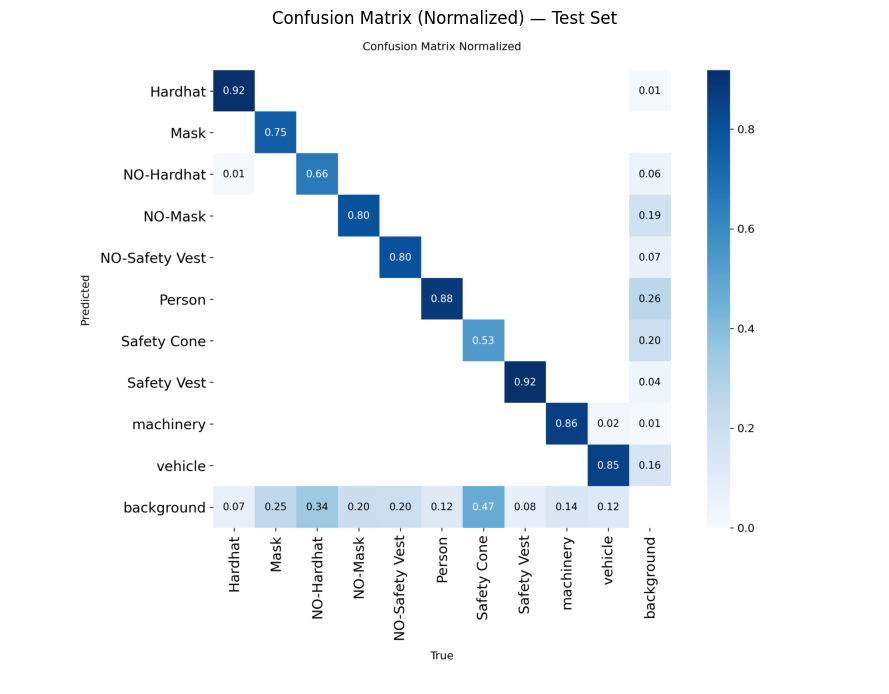

24383

In [ ]:

import matplotlib.image as mpimg

cm_path = sorted((PROJECT_ROOT / "runs_eval").glob("test_eval*/confusion_matrix_normalized.png"),
                 key=lambda p: p.stat().st_mtime, reverse=True)
if cm_path:
    fig, ax = plt.subplots(figsize=(9, 8))
    ax.imshow(mpimg.imread(cm_path[0]))
    ax.axis('off')
    ax.set_title("Confusion Matrix (Normalized) — Test Set")
    plt.tight_layout()
    plt.savefig(str(FIG_DIR / "confusion_matrix.png"), dpi=130, bbox_inches='tight')
    plt.show()
plt.close('all')
import gc; gc.collect()


**Interpretasi singkat:** Model mencapai **mAP@50 ≈ 82%** dan **precision ≈ 92%** pada test set independen — artinya ketika model menyatakan ada pelanggaran/kelengkapan APD, hasilnya *reliable* (rendah *false alarm*). Recall untuk kelas kritikal seperti `NO-Hardhat` relatif lebih rendah dibanding kelas lain, artinya model masih bisa melewatkan sebagian kasus pelanggaran — ini menjadi salah satu fokus perbaikan pada bagian *Limitations*.

##Inference & Visualisasi Prediksi

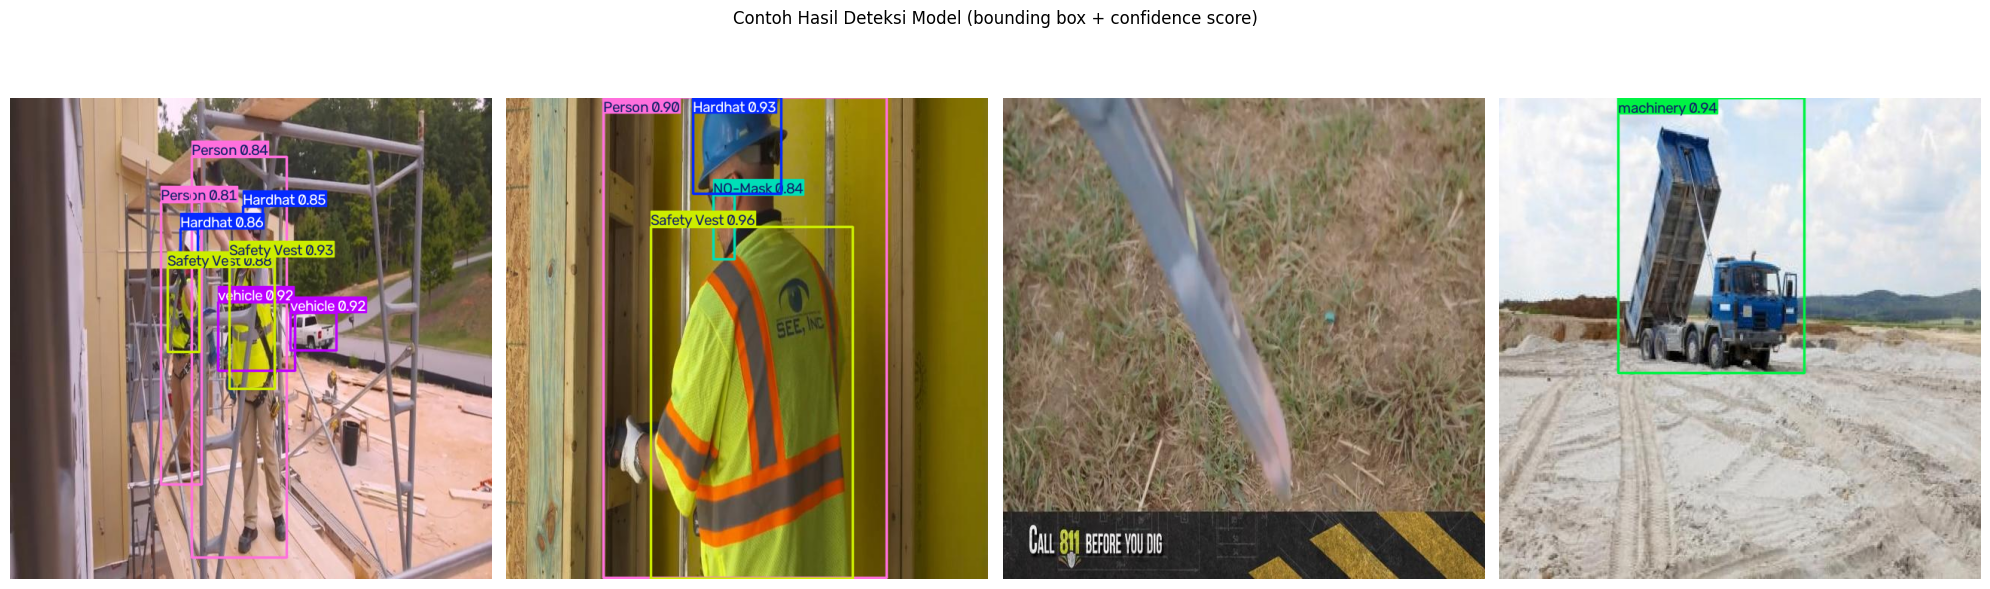

10254

In [ ]:

sample_test = random.sample(list(IMG_DIR.glob("*.jpg")), 4)
results = model.predict(source=[str(p) for p in sample_test], imgsz=512, conf=0.35, verbose=False)

fig, axes = plt.subplots(1, 4, figsize=(20, 6))
for ax, r in zip(axes, results):
    ax.imshow(cv2.cvtColor(r.plot(), cv2.COLOR_BGR2RGB))
    ax.axis('off')
fig.suptitle("Contoh Hasil Deteksi Model (bounding box + confidence score)", y=1.02)
plt.tight_layout()
plt.savefig(str(FIG_DIR / "inference_samples.png"), dpi=130, bbox_inches='tight')
plt.show()
plt.close('all')
import gc; gc.collect()


##Business Logic Layer — Simulasi Sistem Notifikasi HSSE

Meniru fitur *"Detect non-compliance usage of PPE"* pada Case Study i-CCTV di materi workshop: hasil deteksi mentah (bounding box) perlu diterjemahkan menjadi **keputusan bisnis** (compliant / violation) dan **notifikasi otomatis**, bukan berhenti di tingkat deteksi objek saja.

**Rule sederhana yang diterapkan:**
- Jika pada satu frame terdeteksi kelas `NO-Hardhat`, `NO-Mask`, atau `NO-Safety Vest` → frame ditandai **VIOLATION**.
- Jika hanya terdeteksi kelas *compliant* (`Hardhat`, `Mask`, `Safety Vest`, `Person`) tanpa kelas `NO-*` → frame ditandai **COMPLIANT**.
- Setiap `VIOLATION` disimulasikan memicu notifikasi (analog *"findings notified via MS Teams"* pada studi kasus asli).

In [ ]:

import gc

VIOLATION_CLASSES = {'NO-Hardhat', 'NO-Mask', 'NO-Safety Vest'}

def check_compliance(result, class_names, conf_thres=0.35):
    detected = [class_names[int(b.cls)] for b in result.boxes if float(b.conf) >= conf_thres]
    violations = [d for d in detected if d in VIOLATION_CLASSES]
    status = "VIOLATION" if violations else "COMPLIANT"
    return status, violations, detected

all_images = sorted(IMG_DIR.glob("*.jpg"))

# stream=True + generator loop -> proses satu-per-satu agar hemat memori
# (menghindari menahan seluruh 82 hasil deteksi di RAM sekaligus)
records = []
result_stream = model.predict(source=[str(p) for p in all_images], imgsz=512, conf=0.35,
                               verbose=False, stream=True)
for img_path, r in zip(all_images, result_stream):
    status, violations, detected = check_compliance(r, CLASS_NAMES)
    records.append({
        "image": img_path.name,
        "status": status,
        "violation_types": ", ".join(sorted(set(violations))) if violations else "-",
        "n_detections": len(detected)
    })
    del r
gc.collect()

compliance_df = pd.DataFrame(records)
compliance_df.head(10)


,image,status,violation_types,n_detections
0,-4405-_png_jpg.rf.82b5c10b2acd1cfaa24259ada8e5...,VIOLATION,NO-Safety Vest,3
1,000005_jpg.rf.96e9379ccae638140c4a90fc4b700a2b...,VIOLATION,NO-Mask,6
2,002551_jpg.rf.ce4b9f934161faa72c80dc6898d37b2d...,VIOLATION,"NO-Mask, NO-Safety Vest",8
3,003357_jpg.rf.9867f91e88089bb68dc95947d5116d14...,VIOLATION,"NO-Mask, NO-Safety Vest",6
4,004063_jpg.rf.1b7cdc4035bcb24ef69b8798b444053e...,VIOLATION,"NO-Hardhat, NO-Safety Vest",18
5,004763_jpg.rf.46484e6ca73caeaa9de45822cf1085a9...,VIOLATION,"NO-Mask, NO-Safety Vest",12
6,006463_jpg.rf.02f19082420ecc5537b9d59abbe6050c...,VIOLATION,"NO-Mask, NO-Safety Vest",35
7,006672_jpg.rf.87d5978c486feb53177408cf00a0d87f...,VIOLATION,NO-Mask,23
8,0_jpg.rf.2ff49f74309118f169e07aa12564df87.jpg,COMPLIANT,-,16
9,2008_008320_jpg.rf.bd34011d46f82f9410d95f00e56...,VIOLATION,"NO-Hardhat, NO-Mask",5


In [ ]:

# "Alert log" simulasi notifikasi HSSE (5 contoh)
alerts = compliance_df[compliance_df.status == "VIOLATION"].head(5)
print(f"{'='*70}\n SIMULASI ALERT NOTIFICATION -> HSSE TEAM (MS Teams)\n{'='*70}")
for _, row in alerts.iterrows():
    print(f"[ALERT] {row['image']}  |  Pelanggaran terdeteksi: {row['violation_types']}")
print(f"{'='*70}")


 SIMULASI ALERT NOTIFICATION -> HSSE TEAM (MS Teams)
[ALERT] -4405-_png_jpg.rf.82b5c10b2acd1cfaa24259ada8e599fe.jpg  |  Pelanggaran terdeteksi: NO-Safety Vest
[ALERT] 000005_jpg.rf.96e9379ccae638140c4a90fc4b700a2b.jpg  |  Pelanggaran terdeteksi: NO-Mask
[ALERT] 002551_jpg.rf.ce4b9f934161faa72c80dc6898d37b2d.jpg  |  Pelanggaran terdeteksi: NO-Mask, NO-Safety Vest
[ALERT] 003357_jpg.rf.9867f91e88089bb68dc95947d5116d14.jpg  |  Pelanggaran terdeteksi: NO-Mask, NO-Safety Vest
[ALERT] 004063_jpg.rf.1b7cdc4035bcb24ef69b8798b444053e.jpg  |  Pelanggaran terdeteksi: NO-Hardhat, NO-Safety Vest


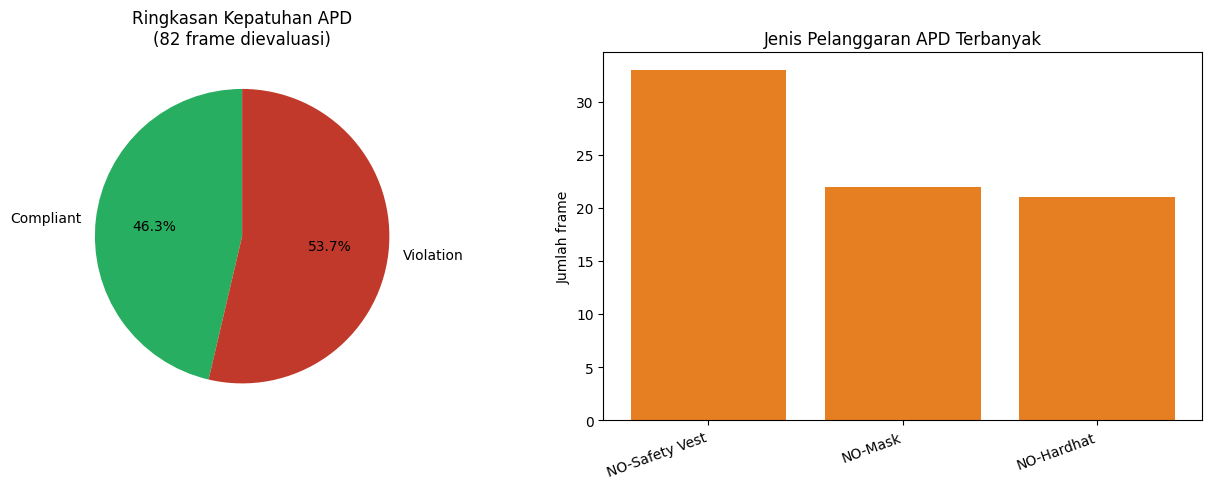

Compliance rate: 46.3%  |  Violation frames: 44/82


In [ ]:

n_violation = (compliance_df.status == "VIOLATION").sum()
n_compliant = (compliance_df.status == "COMPLIANT").sum()
compliance_rate = n_compliant / len(compliance_df) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].pie([n_compliant, n_violation], labels=["Compliant", "Violation"],
            autopct='%1.1f%%', colors=['#27ae60', '#c0392b'], startangle=90)
axes[0].set_title(f"Ringkasan Kepatuhan APD\n({len(compliance_df)} frame dievaluasi)")

viol_types = compliance_df[compliance_df.status == "VIOLATION"]["violation_types"].str.split(", ").explode()
viol_counts = viol_types.value_counts()
axes[1].bar(viol_counts.index, viol_counts.values, color='#e67e22')
axes[1].set_title("Jenis Pelanggaran APD Terbanyak")
axes[1].set_ylabel("Jumlah frame")
plt.setp(axes[1].get_xticklabels(), rotation=20, ha='right')

plt.tight_layout()
plt.savefig(str(FIG_DIR / "compliance_dashboard.png"), dpi=130)
plt.show()
plt.close('all')
import gc; gc.collect()

print(f"Compliance rate: {compliance_rate:.1f}%  |  Violation frames: {n_violation}/{len(compliance_df)}")


##Estimasi Dampak Bisnis (Value Creation)

Mengacu pada *takeaway* CRISP-DM di materi workshop ("*Calculate the value created — tangible or non-tangible*"), berikut estimasi ilustratif dampak penerapan sistem ini pada operasi rig (angka bersifat asumsi untuk ilustrasi, perlu divalidasi dengan data operasional riil):

In [ ]:

assumptions = pd.DataFrame({
    "Metrik": [
        "Cakupan pengawasan (before)",
        "Cakupan pengawasan (after, AI-assisted)",
        "Waktu deteksi pelanggaran (manual)",
        "Waktu deteksi pelanggaran (AI real-time)",
        "Precision model (false-alarm rendah)",
        "Potensi pengurangan beban HSSE Observer"
    ],
    "Nilai": [
        "2 rig / observer (human-only)",
        "Seluruh rig termonitor 24/7 (human+AI)",
        "Tergantung ronde observer (menit-jam)",
        "< 1 menit (real-time notification)",
        f"{summary.loc[0,'Value']}",
        "Observer fokus ke verifikasi & intervensi, bukan pemantauan manual terus-menerus"
    ]
})
assumptions


,Metrik,Nilai
0,Cakupan pengawasan (before),2 rig / observer (human-only)
1,"Cakupan pengawasan (after, AI-assisted)",Seluruh rig termonitor 24/7 (human+AI)
2,Waktu deteksi pelanggaran (manual),Tergantung ronde observer (menit-jam)
3,Waktu deteksi pelanggaran (AI real-time),< 1 menit (real-time notification)
4,Precision model (false-alarm rendah),92.27%
5,Potensi pengurangan beban HSSE Observer,"Observer fokus ke verifikasi & intervensi, buk..."


##Limitations & Future Work

1. **Domain gap** — Model dilatih pada dataset *construction site* umum, bukan citra CCTV rig migas asli. Sebelum *deployment* produksi, model perlu **di-*fine-tune* ulang** menggunakan citra rig migas aktual (termasuk kondisi malam hari, hujan, sudut kamera CCTV rig) — mengikuti prinsip CRISP-DM *"start from white box, end with advanced algorithm"* pada materi workshop.
2. **Recall pelanggaran kritikal** (`NO-Hardhat`, `Safety Cone`) masih dapat ditingkatkan — perlu augmentasi data & class-balancing.
3. **Belum mencakup fitur *Under Suspended Load Detection*** (Feature #2 pada studi kasus asli) yang membutuhkan dataset crane/hook terpisah.
4. **Belum ada *tracking* antar-frame** (mis. DeepSORT) untuk menghindari duplikasi alert dari objek yang sama pada video real-time — pada implementasi asli, hal ini ditangani `instance_reset_timeout` & `non_compliance_delay` (lihat referensi repo).
5. **Validasi lapangan** diperlukan untuk mengkuantifikasi dampak bisnis riil (pengurangan NoA — Number of Accident, waktu respons HSSE) sebagaimana dilaporkan pada studi kasus asli (target: *Maintain 0 Number of Accident*).

##Referensi

- Nugroho, J. (2026). *AI and Machine Learning in Oil & Gas Industry* — Student Workshop "Innovation in Upstream Oil & Gas with AI/ML and Data Analysis".
- Rizki, F.F., et al. (2023). *Artificial Intelligence (AI) Based — Under Suspended Load Detection: Case Study in Rokan Drilling & Completion Operation.* SPE-214018-MS. https://doi.org/10.2118/214018-MS
- Roboflow Universe — *Construction Site Safety Image Dataset*. https://universe.roboflow.com/roboflow-universe-projects/construction-site-safety
- VoxDroid (2025). *Construction-Site-Safety-PPE-Detection* (YOLOv8s fine-tuned weights, MIT License). https://github.com/VoxDroid/Construction-Site-Safety-PPE-Detection
- Jocher, G., et al. Ultralytics YOLOv8. https://docs.ultralytics.com
